In [6]:
import pickle
import autoslo.utils.paths as pu
import os
from collections import defaultdict
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [2]:
cluster_type = "provisioned"
d = {}

In [4]:
for cluster_id in tqdm(range(200)):

    classification_path = os.path.join("/ssd1/markakis/redset_byproducts", cluster_type, f"{cluster_id}", f"template_classification.pkl")
    if not os.path.exists(classification_path) or cluster_id in d:
        continue
    try:
        with open(classification_path, "rb") as f:
            classification = pickle.load(f)

        classification_counts: dict[str, int] = defaultdict(int)
        for c in classification["classification"].values():
            classification_counts[c] += 1
        d[cluster_id] = classification_counts
    except Exception as e:
        print(f"Error processing cluster {cluster_id}: {e}")

  0%|          | 0/200 [00:00<?, ?it/s]

Error processing cluster 49: Ran out of input
Error processing cluster 109: pickle data was truncated


In [15]:
df = pd.DataFrame(d).T.fillna(0).astype(int)
df['total'] = df.sum(axis=1)
df['frac_ad-hoc'] = df['ad-hoc'] / df['total']
df['frac_normal'] = df['normal'] / df['total']
df['frac_windowed'] = df['windowed'] / df['total']
df

,ad-hoc,normal,windowed,total,frac_ad-hoc,frac_normal,frac_windowed
0,1498471,2,2218,1500691,0.998521,0.000001,0.001478
1,945172,0,16,945188,0.999983,0.000000,0.000017
2,4105131,0,392,4105523,0.999905,0.000000,0.000095
3,195,0,0,195,1.000000,0.000000,0.000000
4,2358689,0,801,2359490,0.999661,0.000000,0.000339
...,...,...,...,...,...,...,...
195,2329,0,0,2329,1.000000,0.000000,0.000000
196,655,0,0,655,1.000000,0.000000,0.000000
197,6,0,0,6,1.000000,0.000000,0.000000
198,13,0,0,13,1.000000,0.000000,0.000000


In [17]:
df = df.sort_values('frac_ad-hoc', ascending=True)
df.head(20)

,ad-hoc,normal,windowed,total,frac_ad-hoc,frac_normal,frac_windowed
58,1074,0,47,1121,0.958073,0.000000,0.041927
57,1931,1,56,1988,0.971328,0.000503,0.028169
65,890,16,9,915,0.972678,0.017486,0.009836
75,1124,8,2,1134,0.991182,0.007055,0.001764
113,21894,0,178,22072,0.991935,0.000000,0.008065
185,253332,1,2023,255356,0.992074,0.000004,0.007922
55,24448,2,107,24557,0.995561,0.000081,0.004357
165,499,1,1,501,0.996008,0.001996,0.001996
28,212264,0,700,212964,0.996713,0.000000,0.003287
161,296883,3,634,297520,0.997859,0.000010,0.002131


In [20]:
    
def check(cluster_id):
    columns = ['cluster_size', 'arrival_timestamp', 'feature_fingerprint', 'query_type', 'queue_duration_ms', 'execution_duration_ms']
    df = pd.read_parquet(pu.get_redset_raw_data(cluster_id=cluster_id), columns=columns)

    df['execution_duration_s'] = df['execution_duration_ms'] / 1000

    # print(df.shape)
    # print(df['cluster_size'].value_counts())

    df['arrival_hour'] = df['arrival_timestamp'].dt.floor('H')
    df['hour_of_day'] = df['arrival_timestamp'].dt.hour
    df['day'] = df['arrival_timestamp'].dt.date
    df['on_weekend'] = df['arrival_timestamp'].dt.dayofweek >= 5
    df['day_of_week'] = df['arrival_timestamp'].dt.dayofweek
    df['week'] = df['arrival_timestamp'].dt.isocalendar().week

    # Plot a 2*2 grid of plots.
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))

    # Top left: number of queries per iso week.
    weekly_counts = df.groupby(["week"]).size()
    weekly_counts.plot(kind="bar", ax=axs[0, 0])
    axs[0, 0].set_xlabel("Week Number")
    axs[0, 0].set_ylabel("Number of Queries")
    axs[0, 0].set_title(f"Weekly Query Counts")

    # Top right: number of queries per day of week.
    grouped = (
        df.groupby("day")
        .agg({"arrival_timestamp": "size", "day_of_week": "first"})
        .rename(columns={"arrival_timestamp": "num_queries"})
    )
    mean_over_day_of_week = grouped.groupby("day_of_week")["num_queries"].mean()
    normalized = mean_over_day_of_week / mean_over_day_of_week.sum()
    normalized.plot(kind="bar", ax=axs[0, 1])
    axs[0, 1].set_xticks(ticks=range(7))
    axs[0, 1].set_xticklabels(
        [
            "Monday",
            "Tuesday",
            "Wednesday",
            "Thursday",
            "Friday",
            "Saturday",
            "Sunday",
        ],
        rotation=45,
    )
    axs[0, 1].set_xlabel("Day of Week")
    axs[0, 1].set_ylabel("Fraction of Weekly Queries")
    axs[0, 1].set_title(f"Query Counts by Day of Week")

    # Bottom left: number of queries per hour of day.
    hourly_counts = df.groupby("hour_of_day").size()
    normalized = hourly_counts / hourly_counts.sum()
    normalized.plot(kind="bar", ax=axs[1, 0])
    axs[1, 0].set_xlabel("Hour of Day")
    axs[1, 0].set_ylabel("Fraction of Daily Queries")
    axs[1, 0].set_title(f"Hourly Query Counts")

    # Bottom right: Bucketized latency distribution per hour of day.
    df['latency_s'] = (df['execution_duration_ms'] + df['queue_duration_ms']) / 1000
    latency_by_hour = df.groupby("hour_of_day")["latency_s"].apply(list)
    bucket_left_edges = [0, 1, 10, 60]


    def bucketize(latencies):
        buckets = [0] * (len(bucket_left_edges))
        for latency in latencies:
            bucket_index = len(bucket_left_edges) - 1
            while bucket_index > 0 and latency < bucket_left_edges[bucket_index]:
                bucket_index -= 1
            buckets[bucket_index] += 1
        return buckets


    bucketized_latency = latency_by_hour.apply(bucketize)
    bucketized_latency_df = pd.DataFrame(
        bucketized_latency.tolist(),
        index=bucketized_latency.index,
        columns=[f">= {edge}s" for edge in bucket_left_edges],
    )
    # Make the total number of queries per hour the same, to compare the distribution of latencies across hours.
    bucketized_latency_df = bucketized_latency_df.div(bucketized_latency_df.sum(axis=1), axis=0)
    bucketized_latency_df.plot(kind="bar", stacked=True, ax=axs[1, 1])
    axs[1, 1].set_xlabel("Hour of Day")
    axs[1, 1].set_ylabel("Fraction of Queries")
    axs[1, 1].set_title(f"Bucketized Latency Distribution by Hour of Day")
    axs[1, 1].legend(title="Latency Buckets")


    plt.suptitle(f"Query Arrival Patterns for Cluster {cluster_id}", fontsize=16)
    plt.tight_layout()
    plt.savefig(f'report_{cluster_id}.png', dpi=300)


In [ ]:
for i in tqdm(range(200)):
    check(i)

In [52]:
def info(cluster_id): 
    columns = ['cluster_size', 'arrival_timestamp', 'feature_fingerprint', 'query_type', 'queue_duration_ms', 'execution_duration_ms']
    df = pd.read_parquet(pu.get_redset_raw_data(cluster_id=cluster_id), columns=columns)

    print(df.shape)
    print(df['cluster_size'].value_counts())
    print(df['query_type'].value_counts())
info(12)


(5049109, 6)
cluster_size
2.0    4768490
Name: count, dtype: int64
query_type
analyze    1316319
select     1064332
insert      732863
delete      700628
copy        509685
ctas        391712
other       292418
update       26048
vacuum       13058
unload        2046
Name: count, dtype: int64


In [53]:
cluster_id = 12
columns = ['cluster_size', 'arrival_timestamp', 'feature_fingerprint', 'query_type', 'queue_duration_ms', 'execution_duration_ms']    
df = pd.read_parquet(pu.get_redset_raw_data(cluster_id=cluster_id), columns=columns)

df['latency_s'] = (df['execution_duration_ms'] + df['queue_duration_ms']) / 1000
df.groupby('query_type')['latency_s'].describe()


,count,mean,std,min,25%,50%,75%,max
query_type,,,,,,,,
analyze,1316319.0,0.220402,1.821460,0.002,0.0100,0.0160,0.086,291.750
copy,509685.0,0.231100,0.681343,0.052,0.0910,0.1190,0.188,182.195
ctas,391712.0,46.822546,124.892981,0.005,0.2100,2.6700,36.728,20615.649
delete,700628.0,9.458352,24.625400,0.001,0.1030,0.6620,6.417,2174.968
insert,732863.0,3.174731,20.350716,0.008,0.1180,0.3310,1.039,2817.675
other,292418.0,0.002624,0.125782,0.000,0.0000,0.0000,0.001,28.415
select,1064332.0,2.043529,29.880486,0.003,0.1140,0.2610,0.592,6692.066
unload,2046.0,337.077341,628.666431,0.195,9.4835,72.9095,412.732,8431.592
update,26048.0,0.320251,3.360981,0.009,0.0390,0.0540,0.104,219.724


/tmp/ipykernel_754951/2569148823.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['arrival_hour'] = df['arrival_timestamp'].dt.floor('H')
/tmp/ipykernel_754951/2569148823.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_hours = pd.date_range(start=df['arrival_hour'].min(), end=df['arrival_hour'].max(), freq='H')


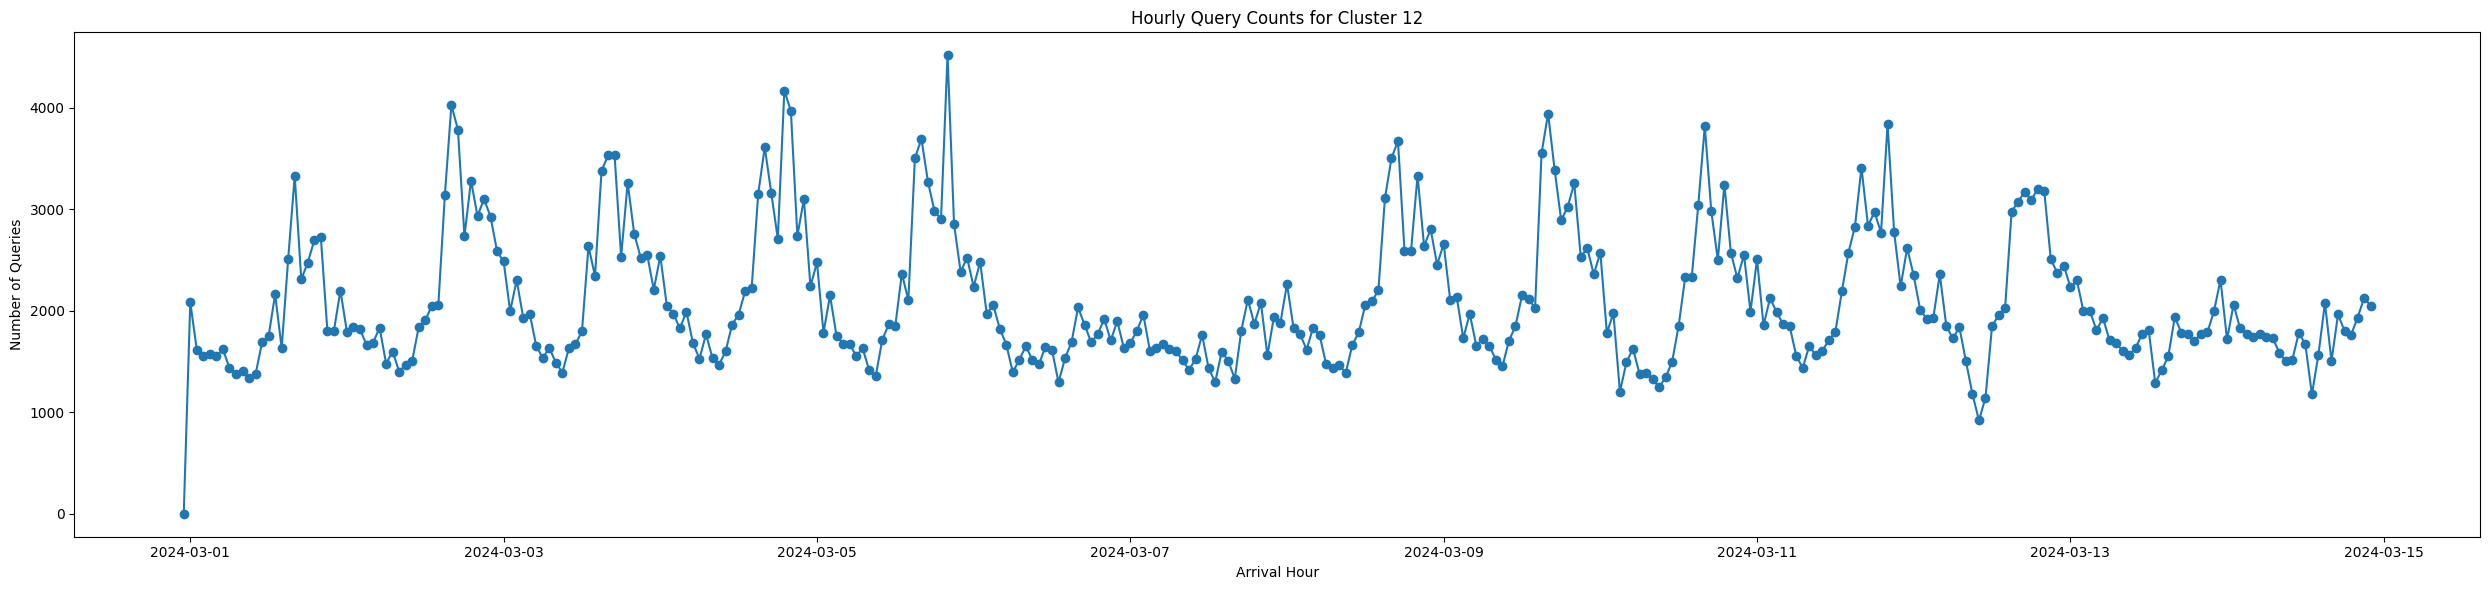

In [49]:
# Plot queries binned by day and hour
import matplotlib.pyplot as plt
df['arrival_hour'] = df['arrival_timestamp'].dt.floor('H')  
hourly_counts = df.groupby('arrival_hour').size()

# Reindex to add missing hours with 0 counts
all_hours = pd.date_range(start=df['arrival_hour'].min(), end=df['arrival_hour'].max(), freq='H')
hourly_counts = hourly_counts.reindex(all_hours, fill_value=0)

# Only the first week
hourly_counts = hourly_counts[hourly_counts.index < (hourly_counts.index.min() + pd.Timedelta(days=14))]


fig, ax = plt.subplots(figsize=(25, 6))
ax.plot(hourly_counts.index, hourly_counts.values, marker='o')

#ax.set_xticks(hourly_counts.index[::24])  # Show one tick per day
# ax.set_xticklabels(hourly_counts.index[::24].strftime('%Y-%m-%d'), rotation=45)
ax.set_xlabel('Arrival Hour')
ax.set_ylabel('Number of Queries')
ax.set_title(f'Hourly Query Counts for Cluster {cluster_id}')
plt.tight_layout()
plt.show()

In [40]:
hourly_counts.index

DatetimeIndex(['2024-03-01 00:00:00', '2024-03-01 01:00:00',
               '2024-03-01 02:00:00', '2024-03-01 03:00:00',
               '2024-03-01 04:00:00', '2024-03-01 05:00:00',
               '2024-03-01 06:00:00', '2024-03-01 07:00:00',
               '2024-03-01 08:00:00', '2024-03-01 09:00:00',
               ...
               '2024-05-30 14:00:00', '2024-05-30 15:00:00',
               '2024-05-30 16:00:00', '2024-05-30 17:00:00',
               '2024-05-30 18:00:00', '2024-05-30 19:00:00',
               '2024-05-30 20:00:00', '2024-05-30 21:00:00',
               '2024-05-30 22:00:00', '2024-05-30 23:00:00'],
              dtype='datetime64[ns]', length=2184, freq='h')

In [41]:
hourly_counts.index[::12]

DatetimeIndex(['2024-03-01 00:00:00', '2024-03-01 12:00:00',
               '2024-03-02 00:00:00', '2024-03-02 12:00:00',
               '2024-03-03 00:00:00', '2024-03-03 12:00:00',
               '2024-03-04 00:00:00', '2024-03-04 12:00:00',
               '2024-03-05 00:00:00', '2024-03-05 12:00:00',
               ...
               '2024-05-26 00:00:00', '2024-05-26 12:00:00',
               '2024-05-27 00:00:00', '2024-05-27 12:00:00',
               '2024-05-28 00:00:00', '2024-05-28 12:00:00',
               '2024-05-29 00:00:00', '2024-05-29 12:00:00',
               '2024-05-30 00:00:00', '2024-05-30 12:00:00'],
              dtype='datetime64[ns]', length=182, freq='12h')

In [38]:
hourly_counts.tail(30)

2024-05-29 18:00:00    1205
2024-05-29 19:00:00    1112
2024-05-29 20:00:00    1259
2024-05-29 21:00:00    1055
2024-05-29 22:00:00     972
2024-05-29 23:00:00     863
2024-05-30 00:00:00    1425
2024-05-30 01:00:00     719
2024-05-30 02:00:00     845
2024-05-30 03:00:00     974
2024-05-30 04:00:00    1125
2024-05-30 05:00:00    1226
2024-05-30 06:00:00    1666
2024-05-30 07:00:00    1055
2024-05-30 08:00:00    2048
2024-05-30 09:00:00    5360
2024-05-30 10:00:00    1525
2024-05-30 11:00:00    1634
2024-05-30 12:00:00    1745
2024-05-30 13:00:00    1436
2024-05-30 14:00:00    1638
2024-05-30 15:00:00    1899
2024-05-30 16:00:00    1976
2024-05-30 17:00:00    2469
2024-05-30 18:00:00    1523
2024-05-30 19:00:00    1644
2024-05-30 20:00:00    1339
2024-05-30 21:00:00    1373
2024-05-30 22:00:00    1544
2024-05-30 23:00:00    1435
Freq: h, dtype: int64

In [104]:
mapping_path = '/ssd1/markakis/redset_byproducts/provisioned/0/template_mapping.pkl'
with open(mapping_path, 'rb') as f:
    mapping = pickle.load(f)
normal_templates = []
windowed_templates = []
for template_desc, template_id in mapping.items():
    if template_id in normal:
        normal_templates.append(template_desc)
    elif template_id in windowed:
        windowed_templates.append(template_desc)
print(f"Normal templates: {normal_templates}")
print(f"Windowed templates: {windowed_templates}")

Normal templates: ['0_None_other_nan_nan_nan_None_None', '0_f8d19e87fbcf130af3cd76bee1ffd848b2971b1bb918501a08c4e5665f2866c8_select_0.0_1.0_0.0_None_None']
Windowed templates: ['0_001d3d594d858c289d9b0344b3ce71376d6f96b91daacd7895e5598af0c94265_select_1.0_0.0_0.0_1391_None', '0_0025b0ba9d25519921cca7cb185fd032b67fb7dd2684911a422a58eb38eb582c_select_1.0_0.0_0.0_355_None', '0_00371baf7b9e61109476432dcae99822193a3f8b30e1e85c7d083e3c0e56af49_select_10.0_0.0_0.0_35659_None', '0_00371baf7b9e61109476432dcae99822193a3f8b30e1e85c7d083e3c0e56af49_select_10.0_0.0_0.0_46998_None', '0_00371baf7b9e61109476432dcae99822193a3f8b30e1e85c7d083e3c0e56af49_select_10.0_0.0_0.0_66666_None', '0_008963c526e99dc7ccdaa2512887ce67197e6d182da253224d33e729146061fb_select_1.0_0.0_0.0_1330_None', '0_008963c526e99dc7ccdaa2512887ce67197e6d182da253224d33e729146061fb_select_1.0_0.0_0.0_1331_None', '0_00bc9d40fb3dbe2cc1334dca08d20a0060fa5f86e8d681cf96a6ced68bdb07ab_select_18.0_0.0_0.0_140431_None', '0_00bc9d40fb3dbe2cc133

In [106]:
fingerprint_df

,instance_id,cluster_size,user_id,database_id,query_id,arrival_timestamp,compile_duration_ms,queue_duration_ms,execution_duration_ms,feature_fingerprint,was_aborted,was_cached,cache_source_query_id,query_type,num_permanent_tables_accessed,num_external_tables_accessed,num_system_tables_accessed,read_table_ids,write_table_ids,mbytes_scanned,mbytes_spilled,num_joins,num_scans,num_aggregations,execution_duration_s,arrival_hour
33344,0,NaN,2,0,3531443,2024-03-01 13:00:37.684285,0.0,0,38089,f8d19e87fbcf130af3cd76bee1ffd848b2971b1bb918501a08c4e5665f2866c8,0,0,NaN,select,0.0,1.0,0.0,None,None,0.0,91.0,0,0,0,38.089,2024-03-01 13:00:00
33418,0,NaN,2,0,3680266,2024-03-01 13:01:16.338314,0.0,0,37025,f8d19e87fbcf130af3cd76bee1ffd848b2971b1bb918501a08c4e5665f2866c8,0,0,NaN,select,0.0,1.0,0.0,None,None,0.0,0.0,0,0,0,37.025,2024-03-01 13:00:00
33455,0,NaN,2,0,3105285,2024-03-01 13:01:57.347821,0.0,0,40525,f8d19e87fbcf130af3cd76bee1ffd848b2971b1bb918501a08c4e5665f2866c8,0,0,NaN,select,0.0,1.0,0.0,None,None,0.0,0.0,0,0,0,40.525,2024-03-01 13:00:00
33775,0,NaN,2,0,3355792,2024-03-01 13:02:43.339276,0.0,0,39700,f8d19e87fbcf130af3cd76bee1ffd848b2971b1bb918501a08c4e5665f2866c8,0,0,NaN,select,0.0,1.0,0.0,None,None,0.0,0.0,0,0,0,39.700,2024-03-01 13:00:00
34348,0,NaN,2,0,2758532,2024-03-01 13:03:20.963174,0.0,0,37965,f8d19e87fbcf130af3cd76bee1ffd848b2971b1bb918501a08c4e5665f2866c8,0,0,NaN,select,0.0,1.0,0.0,None,None,0.0,0.0,0,0,0,37.965,2024-03-01 13:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1008046,0,NaN,2,0,5561218,2024-03-14 23:56:13.791632,1.0,0,34272,f8d19e87fbcf130af3cd76bee1ffd848b2971b1bb918501a08c4e5665f2866c8,0,0,NaN,select,0.0,1.0,0.0,None,None,0.0,0.0,0,0,0,34.272,2024-03-14 23:00:00
1008049,0,NaN,2,0,5634882,2024-03-14 23:56:43.194468,0.0,0,34940,f8d19e87fbcf130af3cd76bee1ffd848b2971b1bb918501a08c4e5665f2866c8,0,0,NaN,select,0.0,1.0,0.0,None,None,0.0,0.0,0,0,0,34.940,2024-03-14 23:00:00
1008050,0,NaN,2,0,5132379,2024-03-14 23:57:26.080822,0.0,0,35175,f8d19e87fbcf130af3cd76bee1ffd848b2971b1bb918501a08c4e5665f2866c8,0,0,NaN,select,0.0,1.0,0.0,None,None,0.0,0.0,0,0,0,35.175,2024-03-14 23:00:00
1008056,0,NaN,2,0,5151047,2024-03-14 23:57:54.068726,1.0,0,35699,f8d19e87fbcf130af3cd76bee1ffd848b2971b1bb918501a08c4e5665f2866c8,0,0,NaN,select,0.0,1.0,0.0,None,None,0.0,0.0,0,0,0,35.699,2024-03-14 23:00:00


In [107]:
df['cluster_size'].value_counts()

cluster_size
3.0    1066324
Name: count, dtype: int64

/tmp/ipykernel_4129002/3913830234.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_hours = pd.date_range(start=fingerprint_df['arrival_hour'].min(), end=fingerprint_df['arrival_hour'].max(), freq='H')


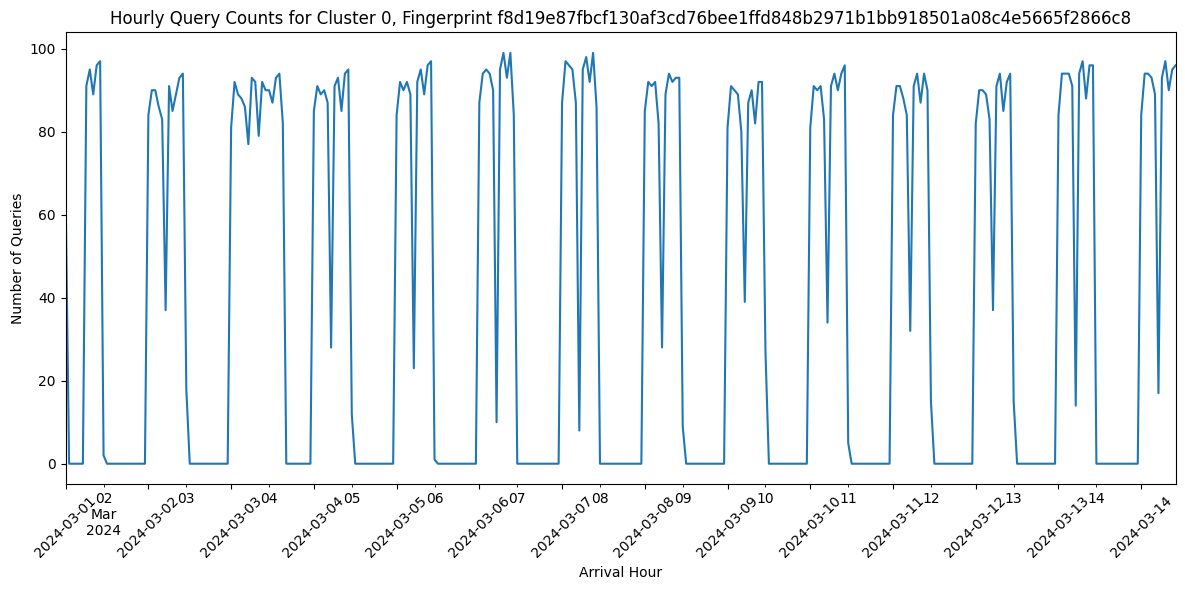

In [105]:
fingerprint = 'f8d19e87fbcf130af3cd76bee1ffd848b2971b1bb918501a08c4e5665f2866c8'
fingerprint_df = df[df['feature_fingerprint'] == fingerprint]
start_day = fingerprint_df['arrival_timestamp'].dt.floor('D').min()
max_day = start_day + pd.Timedelta(days=14)
fingerprint_df = fingerprint_df[(fingerprint_df['arrival_timestamp'] >= start_day) & (fingerprint_df['arrival_timestamp'] <= max_day)]

fingerprint_hourly_counts = fingerprint_df.groupby('arrival_hour').size()

# Add missing hours with zero counts
all_hours = pd.date_range(start=fingerprint_df['arrival_hour'].min(), end=fingerprint_df['arrival_hour'].max(), freq='H')
fingerprint_hourly_counts = fingerprint_hourly_counts.reindex(all_hours, fill_value=0)


fig, ax = plt.subplots(figsize=(12, 6))
fingerprint_hourly_counts.plot(ax=ax)

ax.set_xticks(fingerprint_hourly_counts.index[::24])  # Show one tick per day
ax.set_xticklabels(fingerprint_hourly_counts.index[::24].strftime('%Y-%m-%d'), rotation=45)
ax.set_xlabel('Arrival Hour')
ax.set_ylabel('Number of Queries')
ax.set_title(f'Hourly Query Counts for Cluster {cluster_id}, Fingerprint {fingerprint}')
plt.tight_layout()
plt.show()

In [55]:
fingerprint_df

,instance_id,cluster_size,user_id,database_id,query_id,arrival_timestamp,compile_duration_ms,queue_duration_ms,execution_duration_ms,feature_fingerprint,was_aborted,was_cached,cache_source_query_id,query_type,num_permanent_tables_accessed,num_external_tables_accessed,num_system_tables_accessed,read_table_ids,write_table_ids,mbytes_scanned,mbytes_spilled,num_joins,num_scans,num_aggregations,arrival_hour
1,75,6.0,0,1,1196154,2024-03-01 00:00:21.964040,268.0,0,288,73e98055e6df575f2cfe860ffc8ac2fd58fd3c1bea1d3384c5ff9747b6a33119,0,0,NaN,copy,1.0,0.0,0.0,None,2,576.0,0.0,0,0,2,2024-03-01 00:00:00
3,75,6.0,0,0,1197571,2024-03-01 00:00:32.039353,311.0,0,338,73e98055e6df575f2cfe860ffc8ac2fd58fd3c1bea1d3384c5ff9747b6a33119,0,0,NaN,copy,1.0,0.0,0.0,None,0,528.0,0.0,0,0,2,2024-03-01 00:00:00
7,75,6.0,0,0,1092016,2024-03-01 00:01:04.373831,60.0,0,77,73e98055e6df575f2cfe860ffc8ac2fd58fd3c1bea1d3384c5ff9747b6a33119,0,0,NaN,copy,1.0,0.0,0.0,None,6,132.0,0.0,0,0,2,2024-03-01 00:00:00
8,75,6.0,0,0,1209654,2024-03-01 00:01:05.318201,158.0,0,179,73e98055e6df575f2cfe860ffc8ac2fd58fd3c1bea1d3384c5ff9747b6a33119,0,0,NaN,copy,1.0,0.0,0.0,None,7,314.0,0.0,0,0,2,2024-03-01 00:00:00
9,75,6.0,0,0,873411,2024-03-01 00:01:05.375344,258.0,0,286,73e98055e6df575f2cfe860ffc8ac2fd58fd3c1bea1d3384c5ff9747b6a33119,0,0,NaN,copy,1.0,0.0,0.0,None,0,528.0,0.0,0,0,2,2024-03-01 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1352283,75,1.0,0,0,729135,2024-05-29 23:57:47.365828,178.0,0,181,73e98055e6df575f2cfe860ffc8ac2fd58fd3c1bea1d3384c5ff9747b6a33119,0,0,NaN,copy,1.0,0.0,0.0,None,0,88.0,0.0,0,0,2,2024-05-29 23:00:00
1352285,75,1.0,0,0,854390,2024-05-29 23:58:16.350987,67.0,0,69,73e98055e6df575f2cfe860ffc8ac2fd58fd3c1bea1d3384c5ff9747b6a33119,0,0,NaN,copy,1.0,0.0,0.0,None,4,76.0,0.0,0,0,2,2024-05-29 23:00:00
1352287,75,1.0,0,0,731407,2024-05-29 23:58:53.577300,171.0,0,177,73e98055e6df575f2cfe860ffc8ac2fd58fd3c1bea1d3384c5ff9747b6a33119,0,0,NaN,copy,1.0,0.0,0.0,None,0,88.0,0.0,0,0,2,2024-05-29 23:00:00
1352290,75,1.0,0,1,844260,2024-05-29 23:59:38.757931,154.0,0,170,73e98055e6df575f2cfe860ffc8ac2fd58fd3c1bea1d3384c5ff9747b6a33119,0,0,NaN,copy,1.0,0.0,0.0,None,1,132.0,0.0,0,0,2,2024-05-29 23:00:00
